In [1]:
!pip install MetaTrader5 pandas

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
# import MetaTrader5 as mt5
# import pandas as pd

# # 1. Initialize connection to your active MT5 terminal
# if not mt5.initialize():
#     print("initialize() failed, error code =", mt5.last_error())
#     quit()

# # Your exact 7 European index symbols
# european_indices = ["DE40", "FRA40", "UK100", "EUSTX50", "ESP35", "IT40", "SWI20"]

# for symbol in european_indices:
#     print(f"Fetching 1-minute historical data for {symbol}...")
    
#     # Programmatically ensure the symbol is selected and active in the terminal
#     if not mt5.symbol_select(symbol, True):
#         print(f"-> Failed to select symbol {symbol}. Skipping.")
#         continue
    
#     # Pull the last 100,000 1-minute bars from current position 0 going backwards
#     rates = mt5.copy_rates_from_pos(symbol, mt5.TIMEFRAME_M1, 0, 100000)
    
#     if rates is None or len(rates) == 0:
#         print(f"-> Failed to fetch data for {symbol}. MT5 Error code:", mt5.last_error())
#     else:
#         # Convert to DataFrame
#         df = pd.DataFrame(rates)
#         # Convert unix timestamp to readable UTC datetime
#         df['time'] = pd.to_datetime(df['time'], unit='s')
        
#         # Save directly to CSV
#         filename = f"{symbol}_1min_historical.csv"
#         df.to_csv(filename, index=False)
#         print(f"-> Successfully saved {len(df):,} rows to {filename}")

# # 2. Safely disconnect from MT5
# mt5.shutdown()
# print("All downloads complete!")

Fetching 1-minute historical data for DE40...
-> Failed to fetch data for DE40. MT5 Error code: (-2, 'Terminal: Invalid params')
Fetching 1-minute historical data for FRA40...
-> Failed to fetch data for FRA40. MT5 Error code: (-2, 'Terminal: Invalid params')
Fetching 1-minute historical data for UK100...
-> Failed to fetch data for UK100. MT5 Error code: (-2, 'Terminal: Invalid params')
Fetching 1-minute historical data for EUSTX50...
-> Failed to fetch data for EUSTX50. MT5 Error code: (-2, 'Terminal: Invalid params')
Fetching 1-minute historical data for ESP35...
-> Failed to fetch data for ESP35. MT5 Error code: (-2, 'Terminal: Invalid params')
Fetching 1-minute historical data for IT40...
-> Failed to fetch data for IT40. MT5 Error code: (-2, 'Terminal: Invalid params')
Fetching 1-minute historical data for SWI20...
-> Failed to fetch data for SWI20. MT5 Error code: (-2, 'Terminal: Invalid params')
All downloads complete!


# Multi-Timeframe Resampling Script

In [7]:
import pandas as pd
import os

# 1. List of your exact downloaded CSV files
files = [
    "IT40_M1_202602130905_202608201707.csv",
    "MIDDE50_M1_202509171000_202608201704.csv",
    "NETH25_M1_202602121625_202608201707.csv",
    "NLD.IDX-EUR_1Minute_BID_2020-01-01_00_00-23_59_Etc_UTC.csv",
    "NOR25_M1_202505221532_202608201614.csv",
    "SE30_M1_202509161500_202608201704.csv",
    "SWI20_M1_202601221504_202608201703.csv"
]

# 2. Define the target timeframes required by the client
timeframes = {
    '5m': '5min',
    '15m': '15min',
    '30m': '30min',
    '1H': '1h',
    '2H': '2h',
    '4H': '4h'
}

for file in files:
    if not os.path.exists(file):
        print(f"Skipping {file}: File not found in directory.")
        continue
        
    print(f"\nProcessing {file}...")
    
    # MT5 exports are tab-separated
    df = pd.read_csv(file, sep='\t')
    
    # Normalize column names to lowercase and strip wrapper brackets (e.g., <DATE> -> date)
    df.columns = [col.strip('<>').lower() for col in df.columns]
    
    # Combine date and time columns into a single datetime index
    df['datetime'] = pd.to_datetime(df['date'] + ' ' + df['time'], format='%Y.%m.%d %H:%M:%S')
    df.set_index('datetime', inplace=True)
    df.sort_index(inplace=True)
    
    # Strict financial aggregation rules for OHLCV data
    agg_rules = {
        'open': 'first',
        'high': 'max',
        'low': 'min',
        'close': 'last',
        'tickvol': 'sum'
    }
    
    # Extract a clean base symbol prefix for the output filenames
    symbol_name = file.split('_')[0].split('.')[0]
    
    # Resample into each required timeframe
    for tf_label, tf_rule in timeframes.items():
        resampled_df = df.resample(tf_rule).agg(agg_rules).dropna(subset=['open'])
        
        # Save resampled dataset
        output_filename = f"{symbol_name}_{tf_label}.csv"
        resampled_df.to_csv(output_filename)
        print(f" -> Generated {tf_label}: {len(resampled_df):,} rows saved to {output_filename}")

print("\nAll 7 indices successfully resampled across all 6 timeframes!")


Processing IT40_M1_202602130905_202608201707.csv...
 -> Generated 5m: 20,335 rows saved to IT40_5m.csv
 -> Generated 15m: 6,831 rows saved to IT40_15m.csv
 -> Generated 30m: 3,419 rows saved to IT40_30m.csv
 -> Generated 1H: 1,710 rows saved to IT40_1H.csv
 -> Generated 2H: 921 rows saved to IT40_2H.csv
 -> Generated 4H: 526 rows saved to IT40_4H.csv

Processing MIDDE50_M1_202509171000_202608201704.csv...
 -> Generated 5m: 20,585 rows saved to MIDDE50_5m.csv
 -> Generated 15m: 6,989 rows saved to MIDDE50_15m.csv
 -> Generated 30m: 3,501 rows saved to MIDDE50_30m.csv
 -> Generated 1H: 1,869 rows saved to MIDDE50_1H.csv
 -> Generated 2H: 935 rows saved to MIDDE50_2H.csv
 -> Generated 4H: 702 rows saved to MIDDE50_4H.csv

Processing NETH25_M1_202602121625_202608201707.csv...
 -> Generated 5m: 20,062 rows saved to NETH25_5m.csv
 -> Generated 15m: 6,722 rows saved to NETH25_15m.csv
 -> Generated 30m: 3,431 rows saved to NETH25_30m.csv
 -> Generated 1H: 1,716 rows saved to NETH25_1H.csv
 ->

# Python Feature Engineering Script

In [8]:
pip install pandas-ta

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ------- -------------------------------- 0.5/2.8 MB 5.1 MB/s eta 0:00:01
   ---------------------- ----------------- 1.6/2.8 MB 5.1 MB/s eta 0:00:01
   ---------------------------------------- 2.8/2.8 MB 5.5 MB/s eta 0:00:00
   ---------------------------------------- 0.0/30.3 MB ? eta -:--:--
   - -------------------------------------- 0.8/30.3 MB 9.9 MB/s eta 0:00:03
   --- ------------------------------------ 2.9/30.3 MB 8.5 MB/s eta 0:00:04
   ----- ---------------------------------- 4.2/30.3 MB 6.7 MB/s eta 0:00:04
   ------ --------------------------------- 5.0/30.3 MB 6.9 MB/s eta 0:00:04
   ----------- ---------------------------- 8.4/30.3 MB 8.1 MB/s eta 0:00:03
   ------------- -------------------------- 10.5/30.3 MB 8.5 MB/s eta 0:00:03
   -------------- ------------------------- 11.3/30.3 MB 8.3 MB/s eta 0:00:03
   -----------

  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 5.36.2 requires pandas<3.0,>=1.0, but you have pandas 3.0.5 which is incompatible.

[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### Here is a script template to generate technical features for the resampled files:

In [9]:
import pandas as pd
import pandas_ta as ta
import glob

# Find all resampled timeframe files in your directory
resampled_files = glob.glob("*_[0-9]*m.csv") + glob.glob("*_[0-9]*H.csv")

for file in resampled_files:
    print(f"Engineering features for {file}...")
    
    df = pd.read_csv(file, parse_dates=['datetime'], index_col='datetime')
    
    # 1. Momentum & Trend Indicators using pandas-ta
    df['rsi_14'] = ta.rsi(df['close'], length=14)
    macd = ta.macd(df['close'], fast=12, slow=26, signal=9)
    df = pd.concat([df, macd], axis=1) # Adds MACD, MACD_hist, MACD_signal
    
    # 2. Volatility Indicators
    bbands = ta.bbands(df['close'], length=20, std=2)
    df = pd.concat([df, bbands], axis=1) # Adds BBL, BBM, BBU, BBB, BBP
    df['atr_14'] = ta.atr(df['high'], df['low'], df['close'], length=14)
    
    # 3. Moving Averages
    df['sma_50'] = ta.sma(df['close'], length=50)
    df['ema_20'] = ta.ema(df['close'], length=20)
    
    # 4. Lag Features & Returns (crucial for XGBoost)
    for lag in [1, 2, 3, 5, 10]:
        df[f'return_lag_{lag}'] = df['close'].pct_change(lag)
        df[f'close_lag_{lag}'] = df['close'].shift(lag)
        
    # Drop initial NaN rows created by rolling/lag windows
    df.dropna(inplace=True)
    
    # Save feature-enriched dataset
    output_filename = file.replace('.csv', '_features.csv')
    df.to_csv(output_filename)
    print(f" -> Saved enriched features: {len(df):,} rows to {output_filename}")

print("\nFeature engineering complete across all datasets!")

Engineering features for IT40_15m.csv...
 -> Saved enriched features: 6,782 rows to IT40_15m_features.csv
Engineering features for IT40_30m.csv...
 -> Saved enriched features: 3,370 rows to IT40_30m_features.csv
Engineering features for IT40_5m.csv...
 -> Saved enriched features: 20,286 rows to IT40_5m_features.csv
Engineering features for MIDDE50_15m.csv...
 -> Saved enriched features: 6,940 rows to MIDDE50_15m_features.csv
Engineering features for MIDDE50_30m.csv...
 -> Saved enriched features: 3,452 rows to MIDDE50_30m_features.csv
Engineering features for MIDDE50_5m.csv...
 -> Saved enriched features: 20,536 rows to MIDDE50_5m_features.csv
Engineering features for NETH25_15m.csv...
 -> Saved enriched features: 6,673 rows to NETH25_15m_features.csv
Engineering features for NETH25_30m.csv...
 -> Saved enriched features: 3,382 rows to NETH25_30m_features.csv
Engineering features for NETH25_5m.csv...
 -> Saved enriched features: 20,013 rows to NETH25_5m_features.csv
Engineering feature

# Python Script: Walk-Forward Validation with XGBoost

### This script loads the feature-engineered dataset, sets up a walk-forward split, trains an XGBoost regressor to predict future returns or closing prices, and evaluates its performance across folds.

In [10]:
pip install xgboost scikit-learn

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/48.9 MB ? eta -:--:--
    --------------------------------------- 1.0/48.9 MB 2.5 MB/s eta 0:00:20
   - -------------------------------------- 2.4/48.9 MB 3.8 MB/s eta 0:00:13
   -- ------------------------------------- 3.4/48.9 MB 4.5 MB/s eta 0:00:11
   -- ------------------------------------- 3.4/48.9 MB 4.5 MB/s eta 0:00:11
   ---- ----------------------------------- 5.2/48.9 MB 4.4 MB/s eta 0:00:10
   ----- ---------------------------------- 6.8/48.9 MB 5.0 MB/s eta 0:00:09
   ----- ---------------------------------- 6.8/48.9 MB 5.0 MB/s eta 0:00:09
   ----- ---------------------------------- 7.1/48.9 MB 4.0 MB/s eta 0:00:11
   ----- -----------------


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error
import os

# 1. Load an enriched feature dataset (e.g., IT40 5m or 1H features)
feature_file = "IT40_5m_features.csv" # Update to match your generated feature file

if not os.path.exists(feature_file):
    print(f"Error: {feature_file} not found. Run feature engineering first.")
else:
    df = pd.read_csv(feature_file, parse_dates=['datetime'], index_col='datetime')
    
    # Define Target: Predict the next period's close price (or return)
    # Using shift(-1) means predicting the future price based on current features
    df['target'] = df['close'].shift(-1)
    df.dropna(inplace=True)
    
    # Define features (exclude datetime, open/high/low/close raw values to prevent direct leakage if desired, or keep as needed)
    exclude_cols = ['target', 'open', 'high', 'low', 'close']
    feature_cols = [col for col in df.columns if col not in exclude_cols]
    
    X = df[feature_cols]
    y = df['target']
    
    # 2. Configure Walk-Forward Validation Splits (Expanding Window)
    # For demonstration, we split the data into 5 chronological folds
    n_splits = 5
    fold_size = len(df) // (n_splits + 1)
    
    print(f"Starting Walk-Forward Validation across {n_splits} folds for {feature_file}...\n")
    
    mae_scores = []
    rmse_scores = []
    
    for i in range(n_splits):
        # Define expanding training window and immediate next test block
        train_end = (i + 1) * fold_size
        test_end = train_end + fold_size
        
        X_train, y_train = X.iloc[:train_end], y.iloc[:train_end]
        X_test, y_test = X.iloc[train_end:test_end], y.iloc[train_end:test_end]
        
        if len(X_test) == 0:
            break
            
        # 3. Initialize and Train XGBoost Baseline Model
        model = xgb.XGBRegressor(
            n_estimators=100,
            learning_rate=0.03,
            max_depth=4,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            n_jobs=-1
        )
        
        model.fit(
            X_train, y_train,
            eval_set=[(X_test, y_test)],
            verbose=False
        )
        
        # 4. Predict and Evaluate
        predictions = model.predict(X_test)
        
        mse = mean_squared_error(y_test, predictions)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_test, predictions)
        
        rmse_scores.append(rmse)
        mae_scores.append(mae)
        
        print(f"Fold {i+1} | Train Size: {len(X_train):,} | Test Size: {len(X_test):,} | RMSE: {rmse:.4f} | MAE: {mae:.4f}")

    print("\n--- Walk-Forward Validation Summary ---")
    print(f"Average RMSE across folds: {np.mean(rmse_scores):.4f}")
    print(f"Average MAE across folds: {np.mean(mae_scores):.4f}")

Starting Walk-Forward Validation across 5 folds for IT40_5m_features.csv...

Fold 1 | Train Size: 3,380 | Test Size: 3,380 | RMSE: 464.2030 | MAE: 290.9965
Fold 2 | Train Size: 6,760 | Test Size: 3,380 | RMSE: 513.4168 | MAE: 362.6764
Fold 3 | Train Size: 10,140 | Test Size: 3,380 | RMSE: 1433.0531 | MAE: 997.3822
Fold 4 | Train Size: 13,520 | Test Size: 3,380 | RMSE: 230.3766 | MAE: 217.8252
Fold 5 | Train Size: 16,900 | Test Size: 3,380 | RMSE: 625.4838 | MAE: 511.2749

--- Walk-Forward Validation Summary ---
Average RMSE across folds: 653.3067
Average MAE across folds: 476.0311


### Saving the XGBoost Model:

In [20]:
# Add this right after your XGBoost model finishes training
model.save_model("xgboost_model.json")
print("XGBoost model saved successfully!")

XGBoost model saved successfully!


## Prerequisites

### Before running the script, make sure you have the required deep learning dependencies installed:

In [12]:
pip install torch pytorch-forecasting lightning pandas numpy

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/122.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/122.1 MB ? eta -:--:--
   ---------------------------------------- 0.3/122.1 MB ? eta -:--:--
   ---------------------------------------- 0.8/122.1 MB 2.1 MB/s eta 0:00:57
   ---------------------------------------- 1.3/122.1 MB 2.2 MB/s eta 0:00:55
    --------------------------------------- 1.8/122.1 MB 2.4 MB/s eta 0:00:51
    --------------------------------------- 1.8/122.1 MB 2.4 MB/s eta 0:00:51
   - -------------------------------------- 3.9/122.1 MB 3.0 MB/s eta 0:00:40
   - -------------------------------------- 4.2/122.1 MB 2.7 MB/s eta 0:00:44
   - -------------------------------------- 5.2/122.1 MB 3.1 MB/s eta 0:00:39
   - -------------------------------------- 6.0/122.1 MB 3.1 MB/s eta 0:00:38
   - -------------------------------------- 6.0/122.1 MB 3.1 MB/s eta 0:00:38
   -- -


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Python Script: Temporal Fusion Transformer (TFT) Training

In [14]:
import pandas as pd
import numpy as np
import torch
import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor
from pytorch_forecasting import TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import QuantileLoss
import os

feature_file = "IT40_5m_features.csv" # Update to your target symbol/timeframe

if not os.path.exists(feature_file):
    raise FileNotFoundError(f"{feature_file} not found. Please run feature engineering first.")

df = pd.read_csv(feature_file, parse_dates=['datetime'])

# --- FIX: Clean column names to remove '.' characters ---
df.columns = df.columns.str.replace('.', '_', regex=False)
# --------------------------------------------------------

# Prepare mandatory columns for PyTorch Forecasting
df = df.sort_values('datetime').reset_index(drop=True)
df['time_idx'] = df.index
df['symbol'] = "IT40"  # Group identifier for the asset

target_col = 'close'
# Note the updated column names with underscores instead of dots (e.g., bbl_20_2_0_2_0 if used, or standard features)
known_continuous_cols = ['rsi_14', 'atr_14', 'sma_50', 'ema_20', 'return_lag_1', 'return_lag_5']

# Drop NaN rows
df = df.dropna(subset=[target_col] + known_continuous_cols).reset_index(drop=True)

# Training and Validation Splits
training_cutoff = int(len(df) * 0.8)
train_df = df.iloc[:training_cutoff]
val_df = df.iloc[training_cutoff - 60:]

max_encoder_length = 60
max_prediction_length = 10

training = TimeSeriesDataSet(
    train_df,
    time_idx="time_idx",
    target=target_col,
    group_ids=["symbol"],
    min_encoder_length=max_encoder_length // 2,
    max_encoder_length=max_encoder_length,
    min_prediction_length=1,
    max_prediction_length=max_prediction_length,
    static_categoricals=[],
    static_reals=[],
    time_varying_known_categoricals=[],
    time_varying_known_reals=[],
    time_varying_unknown_categoricals=[],
    time_varying_unknown_reals=known_continuous_cols + [target_col],
    target_normalizer=GroupNormalizer(groups=["symbol"], transformation=None),
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
)

validation = TimeSeriesDataSet.from_dataset(training, val_df, predict=True, stop_randomization=True)

batch_size = 64
train_dataloader = training.to_dataloader(train=True, batch_size=batch_size, num_workers=0)
val_dataloader = validation.to_dataloader(train=False, batch_size=batch_size * 2, num_workers=0)

tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=0.03,
    hidden_size=32,
    attention_head_size=4,
    dropout=0.2,
    hidden_continuous_size=16,
    output_size=7,
    loss=QuantileLoss(),
    reduce_on_plateau_patience=4,
)

early_stop_callback = EarlyStopping(monitor="val_loss", min_delta=1e-4, patience=5, verbose=False, mode="min")
lr_logger = LearningRateMonitor()

trainer = pl.Trainer(
    max_epochs=20,
    accelerator="auto",
    enable_model_summary=True,
    gradient_clip_val=0.1,
    callbacks=[early_stop_callback, lr_logger],
)

trainer.fit(
    tft,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader,
)

C:\Users\alyhi\AppData\Roaming\Python\Python313\site-packages\lightning\pytorch\utilities\parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
C:\Users\alyhi\AppData\Roaming\Python\Python313\site-packages\lightning\pytorch\utilities\parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
C:\Users\alyhi\AppData\Roaming\Python\Python313\site-packages\lightning\pytorch\trainer\connectors\logger_connector\logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=Tr

┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │      0 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │    352 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │  5.7 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │ 16.1 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │  1.8 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  8.4 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  8.4 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │  2.1 K │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │     64 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │  5.3 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │  2.6 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │  2.2 K │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │  2.2 K │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    231 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 76.6 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 76.6 K                                                                                               
Total estimated model params size (MB): 0.307                                                                      
Modules in train mode: 325                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

C:\Users\alyhi\AppData\Roaming\Python\Python313\site-packages\rich\live.py:231: UserWarning: install "ipywidgets" 
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

C:\Users\alyhi\AppData\Roaming\Python\Python313\site-packages\lightning\pytorch\utilities\_pytree.py:21: 
`isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` 
instead.

C:\Users\alyhi\AppData\Roaming\Python\Python313\site-packages\lightning\pytorch\trainer\connectors\data_connector.p
y:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of 
the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.

C:\Users\alyhi\AppData\Roaming\Python\Python313\site-packages\lightning\pytorch\trainer\connectors\data_connector.p
y:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value 
of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.

### Saving the TFT Model (PyTorch Lightning):

In [21]:
import shutil

# Lightning automatically tracks the best model based on validation loss
best_model_path = trainer.checkpoint_callback.best_model_path
print(f"Best TFT model saved by PyTorch at: {best_model_path}")

# Copy it to your main project directory for easy access
shutil.copy(best_model_path, "tft_model.ckpt")
print("TFT model copied to main directory as 'tft_model.ckpt'!")

Best TFT model saved by PyTorch at: c:\Users\alyhi\Desktop\Forex\lightning_logs\version_0\checkpoints\epoch=18-step=4807.ckpt
TFT model copied to main directory as 'tft_model.ckpt'!


## Loss calculations

In [19]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Generate validation forecasts and retrieve the matching actual future values.
loss_predictions = tft.predict(val_dataloader, mode="raw", return_x=True)
y_true = np.asarray(loss_predictions.x["decoder_target"])
y_pred = np.asarray(loss_predictions.output.prediction[..., 3])

# Flatten all validation horizons into comparable one-dimensional arrays.
y_true = y_true.reshape(-1)
y_pred = y_pred.reshape(-1)

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)

print(f"Regression MAE:  {mae:.4f}")
print(f"Regression RMSE: {rmse:.4f}")

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


C:\Users\alyhi\AppData\Roaming\Python\Python313\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
C:\Users\alyhi\AppData\Roaming\Python\Python313\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.


Regression MAE:  212.6641
Regression RMSE: 217.9292


## Generate & Plot Predictions

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


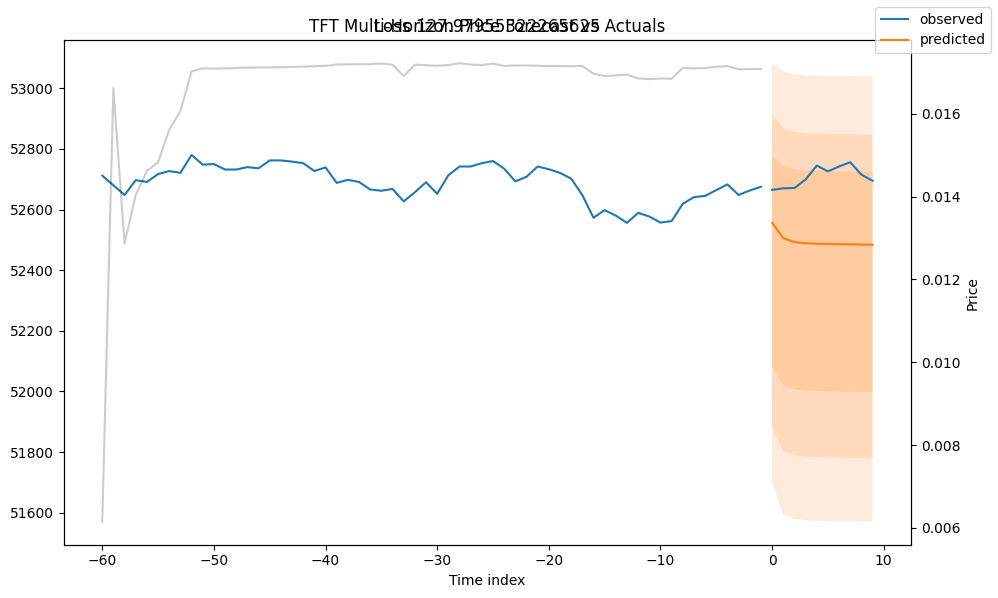

In [16]:
# 1. Generate predictions (store in a single variable)
predictions = tft.predict(val_dataloader, mode="raw", return_x=True)

# 2. Plot predictions for the first validation sample
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

# 3. Use .x and .output directly from the predictions object
tft.plot_prediction(
    predictions.x, 
    predictions.output, 
    idx=0, # Index of the validation sample (change to 1, 2, 3 to see other examples)
    add_loss_to_title=True, 
    ax=ax
)

plt.title("TFT Multi-Horizon Price Forecast vs Actuals")
plt.xlabel("Time Steps")
plt.ylabel("Price")
plt.show()

## Extracting Variable Importance

C:\Users\alyhi\AppData\Local\Temp\ipykernel_16616\373789630.py:17: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figs['encoder_variables'].show()
C:\Users\alyhi\AppData\Local\Temp\ipykernel_16616\373789630.py:22: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figs['decoder_variables'].show()
C:\Users\alyhi\AppData\Local\Temp\ipykernel_16616\373789630.py:27: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figs['attention'].show()


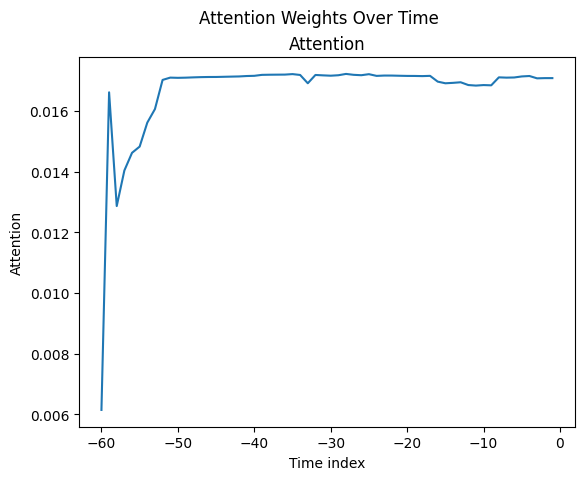

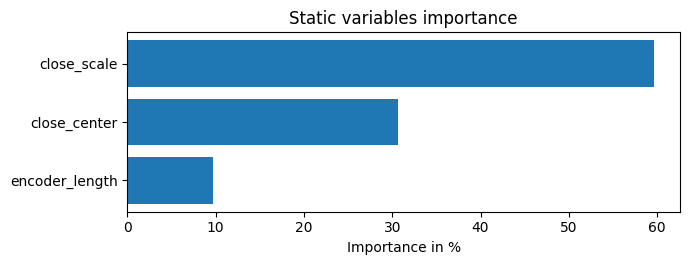

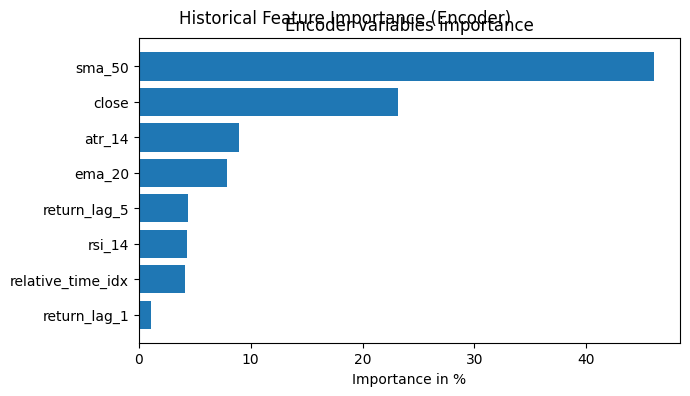

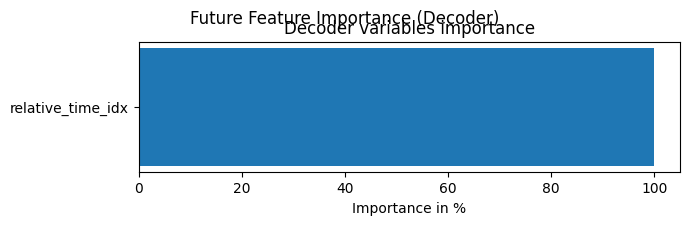

In [17]:
import matplotlib.pyplot as plt

# 1. Generate the interpretation object from the raw predictions
interpretation = tft.interpret_output(predictions.output, reduction="sum")

# 2. Plot the interpretation dictionary 
# This generates multiple matplotlib figures showing attention and feature weights
figs = tft.plot_interpretation(interpretation)

# 3. Display the specific figures
# The `plot_interpretation` method returns a dictionary of figures. 
# We can access and show the most important ones:

# Plot Encoder Variable Importance (Which historical indicators mattered most?)
if 'encoder_variables' in figs:
    figs['encoder_variables'].suptitle("Historical Feature Importance (Encoder)", fontsize=12)
    figs['encoder_variables'].show()

# Plot Decoder Variable Importance (Which future/known variables mattered most?)
if 'decoder_variables' in figs:
    figs['decoder_variables'].suptitle("Future Feature Importance (Decoder)", fontsize=12)
    figs['decoder_variables'].show()

# Plot Attention over time (Does the model look at recent bars or older bars?)
if 'attention' in figs:
    figs['attention'].suptitle("Attention Weights Over Time", fontsize=12)
    figs['attention'].show()